In [ ]:
'''
Box2D의 Env

Action Space; Box([-1. 0. 0.], 1.0, (3,), float32)

Observation Space; Box(0, 255, (96, 96, 3), uint8)

import gymnasium.make("CarRacing-v2")

The easiest control task to learn from pixels - a top-down racing environment. The generated track is random every episode.

Some indicators are shown at the bottom of the window along with the state RGB buffer.
From left to right: true speed, four ABS sensors, steering wheel position, and gyroscope.

Remember: it’s a powerful rear-wheel drive car - don’t press the accelerator and turn at the same time.

If discrete there are 5 actions:
0: do nothing
1: steer left
2: steer right
3: gas
4: brake

Observation Space
A top-down 96x96 RGB image of the car and race track.

Rewards
The reward is -0.1 every frame and +1000/N for every track tile visited, where N is the total number of tiles visited in the track.
For example, if you have finished in 732 frames, your reward is 1000 - 0.1*732 = 926.8 points.

Starting State
The car starts at rest in the center of the road.

Episode Termination
The episode finishes when all the tiles are visited.
The car can also go outside the playfield - that is, far off the track, in which case it will receive -100 reward and die.

lap_complete_percent=0.95 dictates the percentage of tiles that must be visited by the agent before a lap is considered complete.
domain_randomize=False enables the domain randomized variant of the environment. In this scenario, the background and track colours are different on every reset.

continuous=False converts the environment to use discrete action space. The discrete action space has 5 actions: [do nothing, left, right, gas, brake].
'''

In [2]:
import math
import pickle
import random
from collections import namedtuple, deque
from itertools import count

import torch
import cv2
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
def image_preprocessing(img):
    img = cv2.resize(img, dsize=(84, 84))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) / 255.0
    return img

In [5]:
class CarEnvironment(gym.Wrapper):
    def __init__(self, env, skip_frames=2, stack_frames=4, no_operation=5, **kwargs):
        super().__init__(env, **kwargs)
        self._no_operation = no_operation
        self._skip_frames = skip_frames
        self._stack_frames = stack_frames

    def reset(self):
        observation, info = self.env.reset()
        for _ in range(self._no_operation):
            observation, _, _, _, info = self.env.step(0)
        observation = image_preprocessing(observation)
        self.stack_state = np.tile(observation, (self._stack_frames, 1, 1)) # 4, 84, 84
        return self.stack_state, info

    def step(self, action):
        total_reward = 0
        for _ in range(self._skip_frames):
            observation, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        observation = image_preprocessing(observation)
        self.stack_state = np.concatenate((self.stack_state[1:], observation[np.newaxis]), axis=0)
        return self.stack_state, total_reward, terminated, truncated, info

In [6]:
class CNN(nn.Module):
    def __init__(self, in_channels, out_channels, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._n_features = 32 * 9 * 9
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2),
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(self._n_features, 256),
            nn.ReLU(),
            nn.Linear(256, out_channels),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view((-1, self._n_features))
        x = self.fc(x)
        return x

In [7]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [8]:
class DQN:
    def __init__(self, action_space, batch_size=256, gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=1000, lr=0.001):
        self._n_observation = 4
        self._n_actions = 5
        self._action_space = action_space
        self._batch_size = batch_size
        self._gamma = gamma
        self._eps_start = eps_start
        self._eps_end = eps_end
        self._eps_decay = eps_decay
        self._lr = lr
        self._total_steps = 0
        self._evaluate_loss = []
        self.network = CNN(self._n_observation, self._n_actions).to(device)
        self.target_network = CNN(self._n_observation, self._n_actions).to(device)
        self.target_network.load_state_dict(self.network.state_dict())
        self.optimizer = optim.AdamW(self.network.parameters(), lr=self._lr, amsgrad=True)
        self._memory = ReplayMemory(10000)

    def select_action(self, state, evaluation_phase=False):
        sample = random.random()
        eps_threshold = self._eps_end + (self._eps_start - self._eps_end) * math.exp(-1. * self._total_steps / self._eps_decay)
        self._total_steps += 1
        if evaluation_phase:
            with torch.no_grad():
                return self.target_network(state).max(1).indices.view(1, 1)
        elif sample > eps_threshold:
            with torch.no_grad():
                return self.network(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[self._action_space.sample()]], device=device, dtype=torch.long)

    def train(self):
        if len(self._memory) < self._batch_size:
            return
        transitions = self._memory.sample(self._batch_size)
        batch = Transition(*zip(*transitions))
        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.network(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self._batch_size, device=device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_network(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self._gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.network.parameters(), 100)
        self.optimizer.step()
        self._evaluate_loss.append(loss.item())

    def copy_weights(self):
        self.target_network.load_state_dict(self.network.state_dict())

    def get_loss(self):
        return self._evaluate_loss

    def save_model(self, i):
        torch.save(self.target_network.state_dict(), f'model_weights_{i}.pth')

    def load_model(self, i):
        self.target_network.load_state_dict(torch.load(f'model_weights_{i}.pth'))

In [8]:
rewards_per_episode = []
episode_duration = []
average_episode_loss = []
episodes = 1000
C = 5 # Copy 주기
env = gym.make('CarRacing-v2', lap_complete_percent=0.95, continuous=False)
env = CarEnvironment(env)
n_actions = env.action_space
agent = DQN(n_actions)
for episode in range(1, episodes + 1):
    if episode % 10 == 0:
        print(f"{episode} episodes done")
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    episode_total_reward = 0
    for t in count():
        action = agent.select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        episode_total_reward += reward
        done = terminated or truncated
        if terminated:
            next_state = None
            print("Finished the lap successfully!")
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        agent._memory.push(state, action, next_state, reward)
        state = next_state
        agent.train()
        if done:
            if agent._memory.__len__() >= 128:
                episode_duration.append(t + 1)
                rewards_per_episode.append(episode_total_reward)
                ll = agent.get_loss()
                average_episode_loss.append(sum(ll) / len(ll))
            break
        if episode % 100 == 0:
            agent.save_model(episode)
            with open('statistics.pkl', 'wb') as f:
                pickle.dump((episode_duration, rewards_per_episode, average_episode_loss), f)
    if episode % C == 0:
        agent.copy_weights()
agent.save_model(episodes)
with open('statistics.pkl', 'wb') as f:
    pickle.dump((episode_duration, rewards_per_episode, average_episode_loss), f)

10 episodes done


KeyboardInterrupt: 

In [9]:
def plot_statistics(x, y, title, x_axis, y_axis):
    plt.plot(x, y)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.title(title)
    plt.grid(True)
    plt.savefig(f'{title.replace(" ", "_")}.png')
    plt.show()

In [9]:
eval_env = gym.make('CarRacing-v2', continuous=False, render_mode='rgb_array')
eval_env = CarEnvironment(eval_env)
n_actions = eval_env.action_space
agent = DQN(n_actions)
agent.load_model(1000)
frames = []
scores = 0
s, _ = eval_env.reset()
eval_env.np_random = np.random.default_rng(42)
done, ret = False, 0
from PIL import Image as PILImage
def render2img(_img):
    return PILImage.fromarray(_img, "RGB")
handle = display(None, display_id=True)
while not done:
    _render = eval_env.render()
    handle.update(render2img(_render))
    frames.append(_render)
    s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
    a = agent.select_action(s, evaluation_phase=True)
    discrete_action = a.item() % 5
    s_prime, r, terminated, truncated, info = eval_env.step(discrete_action)
    s = s_prime
    ret += r
    done = terminated or truncated
    if terminated:
      print(terminated)
scores += ret
print(scores)
def animate(imgs, video_name, _return=True):
    import cv2
    import os
    import string
    import random
    if video_name is None:
        video_name = ''.join(random.choice(string.ascii_letters) for i in range(18)) + '.webm'
    height, width, layers = imgs[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'VP90')
    video = cv2.VideoWriter(video_name, fourcc, 10, (width, height))
    for img in imgs:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        video.write(img)
    video.release()
animate(frames, None)

RuntimeError: Error(s) in loading state_dict for CNN:
	Missing key(s) in state_dict: "conv.0.weight", "conv.0.bias", "conv.2.weight", "conv.2.bias", "fc.0.weight", "fc.0.bias", "fc.2.weight", "fc.2.bias". 
	Unexpected key(s) in state_dict: "pos_embedding", "cls_token", "patch_embedding.weight", "patch_embedding.bias", "encoder_layer.self_attn.in_proj_weight", "encoder_layer.self_attn.out_proj.weight", "encoder_layer.linear1.weight", "encoder_layer.linear2.weight", "encoder_layer.norm1.weight", "encoder_layer.norm2.weight", "encoder.layers.0.self_attn.in_proj_weight", "encoder.layers.0.self_attn.out_proj.weight", "encoder.layers.0.linear1.weight", "encoder.layers.0.linear2.weight", "encoder.layers.0.norm1.weight", "encoder.layers.0.norm2.weight", "encoder.layers.1.self_attn.in_proj_weight", "encoder.layers.1.self_attn.out_proj.weight", "encoder.layers.1.linear1.weight", "encoder.layers.1.linear2.weight", "encoder.layers.1.norm1.weight", "encoder.layers.1.norm2.weight", "encoder.layers.2

OpenCV: FFMPEG: tag 0x30395056/'VP90' is not supported with codec id 167 and format 'webm / WebM'


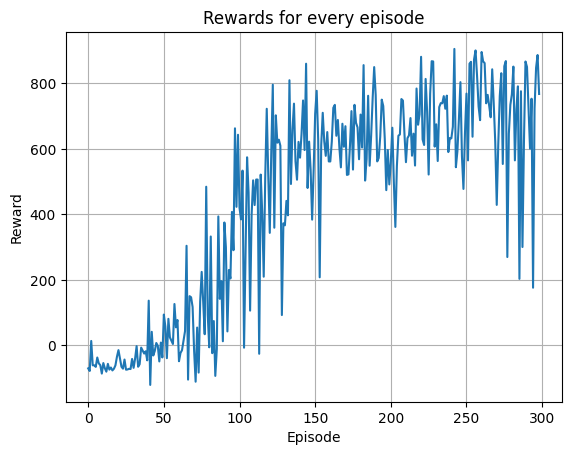

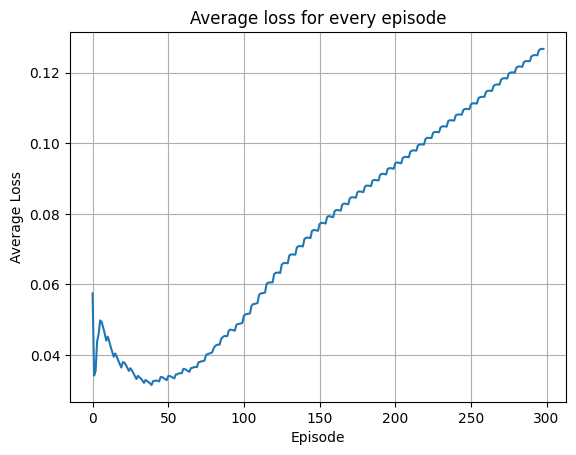

In [ ]:
with open('statistics.pkl', 'rb') as f:
    data_tuple = pickle.load(f)

episode_duration, rewards_per_episode, average_episode_loss = data_tuple

x = [k for k in range(299)]

rewards_per_episode = [tensor.cpu() if tensor.is_cuda else tensor for tensor in rewards_per_episode]

plot_statistics(x, rewards_per_episode, "Rewards for every episode", "Episode", "Reward")
plot_statistics(x, average_episode_loss, "Average loss for every episode", "Episode", "Average Loss")